### I. Compound Data Aquisation for CDK2 kinase from ChEMBL

In [1]:
import math 
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 

from rdkit.Chem import PandasTools
from chembl_webresource_client.new_client import new_client
from tqdm.auto import tqdm

#### I.1 Connect to ChEMBL database + create new_client

In [2]:
targets_api = new_client.target
compounds_api = new_client.molecule
bioactivities_api = new_client.activity

#### I.2 Get target (CDK2/1/4/6/9) data

#### I. 2.1 Fetch target data from ChEMBL

In [3]:
uniprot_id_cdk1 = "P06493"
uniprot_id_cdk2 = "P24941"
uniprot_id_cdk4 = "P11802"
uniprot_id_cdk6 = "Q00534"
uniprot_id_cdk9 = "P50750"

In [4]:
uniprot_ids = [
    uniprot_id_cdk1,
    uniprot_id_cdk2,
    uniprot_id_cdk4,
    uniprot_id_cdk6,
    uniprot_id_cdk9,
]

In [5]:
#we write down our query
#Get target information from ChEMBL but restric it to specific values only
all_targets = []

for uniprot_id in uniprot_ids:
    targets = targets_api.get(target_components__accession=uniprot_id).only(
        "target_chembl_id",
        "organism",
        "pref_name",
        "target_type")
    targets_df = pd.DataFrame.from_records(targets)
    all_targets.append(targets_df)

targets = pd.concat(all_targets, ignore_index=True).reset_index(drop=True)

print("Your data is ready to 'Download'")

Your data is ready to 'Download'


#### I. 2.2 Download target data from ChEMBL

In [6]:
targets_filtered = targets[
    (targets["target_type"] == "SINGLE PROTEIN") &
    (targets["organism"] == "Homo sapiens")
].reset_index(drop=True)

targets_filtered[["pref_name", "target_chembl_id"]]

,pref_name,target_chembl_id
0,Cyclin-dependent kinase 1,CHEMBL308
1,Cyclin-dependent kinase 1,CHEMBL308
2,Cyclin-dependent kinase 2,CHEMBL301
3,Cyclin-dependent kinase 2,CHEMBL301
4,Cyclin-dependent kinase 4,CHEMBL331
5,Cyclin-dependent kinase 4,CHEMBL331
6,Cyclin-dependent kinase 6,CHEMBL2508
7,Cyclin-dependent kinase 6,CHEMBL2508
8,Cyclin-dependent kinase 9,CHEMBL3116
9,Cyclin-dependent kinase 9,CHEMBL3116


#### I. 2.3 Select target (target ChEMBL ID)

In [7]:
cdk_targets = [
    ("CDK1", "CHEMBL308"),
    ("CDK2", "CHEMBL301"),
    ("CDK4", "CHEMBL331"),
    ("CDK6", "CHEMBL2508"),
    ("CDK9", "CHEMBL3116"),
]

#### I.3 Get bioactivty data

In this step, we fetch the bioactivity data and filter it to only consider

* human proteins, 
* bioactivity type IC50, 
* exact measurements (relation `'='`), and
* binding data (assay type `'B'`).

#### I. 3.1 Fetch bioactivity data from ChEMBL

In [8]:
all_bioactivities = []

for kinase_name, ChEMBL_id in cdk_targets:
    bioactivities = bioactivities_api.filter(
        target_chembl_id=ChEMBL_id,
        type="IC50",
        relation='=',
        assay_type='B').only(

        "activity_id",
        "assay_chembl_id",
        "assay_description",
        "assay_type",
        "molecule_chembl_id",
        "type",
        "standard_units",
        "relation",
        "standard_value",
        "target_chembl_id",
        "target_organism",
    )

    bioactivities_df = pd.DataFrame.from_records(bioactivities)
    bioactivities_df["kinase"] = kinase_name

    print(f"{kinase_name} ({ChEMBL_id}): {len(bioactivities_df)} records")
    all_bioactivities.append(bioactivities_df)

bioactivities = pd.concat(all_bioactivities, ignore_index=True).reset_index(drop=True)

print(f"\nTotal combined records: {len(bioactivities)}")

CDK1 (CHEMBL308): 1488 records


CDK2 (CHEMBL301): 2711 records


CDK4 (CHEMBL331): 1590 records
CDK6 (CHEMBL2508): 1002 records


CDK9 (CHEMBL3116): 1922 records

Total combined records: 8713


#### I.3.2 Download bioactivty data

In [9]:
bioactivities_df = pd.DataFrame(bioactivities)
bioactivities_df.head()

,activity_id,assay_chembl_id,assay_description,assay_type,molecule_chembl_id,relation,standard_units,standard_value,target_chembl_id,target_organism,type,units,value,kinase
0,72612,CHEMBL662511,In vitro inhibitory activity against cyclin-de...,B,CHEMBL95827,=,nM,900.0,CHEMBL308,Homo sapiens,IC50,uM,0.9,CDK1
1,72612,CHEMBL662511,In vitro inhibitory activity against cyclin-de...,B,CHEMBL95827,=,nM,900.0,CHEMBL308,Homo sapiens,IC50,uM,0.9,CDK1
2,72615,CHEMBL662511,In vitro inhibitory activity against cyclin-de...,B,CHEMBL420455,=,nM,150000.0,CHEMBL308,Homo sapiens,IC50,uM,150.0,CDK1
3,72620,CHEMBL662511,In vitro inhibitory activity against cyclin-de...,B,CHEMBL100312,=,nM,70000.0,CHEMBL308,Homo sapiens,IC50,uM,70.0,CDK1
4,73687,CHEMBL662511,In vitro inhibitory activity against cyclin-de...,B,CHEMBL296586,=,nM,400.0,CHEMBL308,Homo sapiens,IC50,uM,0.4,CDK1


In [10]:
bioactivities_df.shape

(8713, 14)

- we drop 'units' and 'value' columns

In [11]:
bioactivities_df.drop(['units', 'value'], axis = 1, inplace = True)

#### I.3.3  Preprocessing and filter bioactivity data

1. Convert `standard_value`'s datatype from `str` to `float`
2. Delete entries with missing values
3. Keep only entries with `standard_unit == nM`
4. Delete duplicate molecules
5. Reset `DataFrame` index
6. Rename columns

**1. Convert `standard_value`'s datatype from `str` to `float`**

In [12]:
bioactivities_df.dtypes

activity_id           int64
assay_chembl_id         str
assay_description       str
assay_type              str
molecule_chembl_id      str
relation                str
standard_units          str
standard_value          str
target_chembl_id        str
target_organism         str
type                    str
kinase                  str
dtype: object

In [13]:
bioactivities_df['standard_value'] = bioactivities_df['standard_value'].astype(float)

In [14]:
bioactivities_df.dtypes

activity_id             int64
assay_chembl_id           str
assay_description         str
assay_type                str
molecule_chembl_id        str
relation                  str
standard_units            str
standard_value        float64
target_chembl_id          str
target_organism           str
type                      str
kinase                    str
dtype: object

**2. Delete entries with missing values**

In [15]:
bioactivities_df.isnull().sum()

activity_id           0
assay_chembl_id       0
assay_description     0
assay_type            0
molecule_chembl_id    0
relation              0
standard_units        0
standard_value        0
target_chembl_id      0
target_organism       0
type                  0
kinase                0
dtype: int64

        -> There is no null values

**3. Keep only entries with "standard_unit == nM"**

Before dropping :

In [16]:
print(f"Diffrent units in 'standard_units' column : {bioactivities_df['standard_units'].unique()}")

print(f"Number of non nM entries: {bioactivities_df[bioactivities_df['standard_units'] != 'nM'].shape[0]}")

Diffrent units in 'standard_units' column : <StringArray>
['nM', 'ug.mL-1']
Length: 2, dtype: str
Number of non nM entries: 56


After dropping : 

In [17]:
bioactivities_df = bioactivities_df[bioactivities_df['standard_units'] == 'nM']
print(f"Diffrent units in 'standard_units' column after filtring: {bioactivities_df['standard_units'].unique()}")

Diffrent units in 'standard_units' column after filtring: <StringArray>
['nM']
Length: 1, dtype: str


**4. Delete duplicate molecules**

Sometimes the same molecule (`molecule_chembl_id`) has been tested more than once, in this case, we calcualte the mean of the same molecule tested for the same kinase.

Note other choices could be to keep the one with the best value or a mean value of all assay results for the respective compound.

In [18]:
cols = bioactivities_df.columns.tolist()

[f' {col} has: {bioactivities_df.duplicated(col).sum()} duplicates' for col in cols]

[' activity_id has: 5 duplicates',
 ' assay_chembl_id has: 7785 duplicates',
 ' assay_description has: 8201 duplicates',
 ' assay_type has: 8656 duplicates',
 ' molecule_chembl_id has: 3623 duplicates',
 ' relation has: 8656 duplicates',
 ' standard_units has: 8656 duplicates',
 ' standard_value has: 6629 duplicates',
 ' target_chembl_id has: 8652 duplicates',
 ' target_organism has: 8656 duplicates',
 ' type has: 8656 duplicates',
 ' kinase has: 8652 duplicates']

- i will use the mean to keep only one row representative for duplicated molecules 

In [19]:
bioactivities_df['pIC50'] = -np.log10(bioactivities_df['standard_value'] * 1e-9)

In [20]:
bioactivities_df = (
    bioactivities_df
    .groupby(['molecule_chembl_id', 'kinase'], as_index=False)
    .agg({
        **{col: 'first' for col in bioactivities_df.columns if col not in ['molecule_chembl_id', 'kinase', 'pIC50']},
        'pIC50': 'median'
    })
)

In [21]:
cols = bioactivities_df.columns.tolist()

[f' {col} has: {bioactivities_df.duplicated(col).sum()} duplicates' for col in cols]

[' molecule_chembl_id has: 1969 duplicates',
 ' kinase has: 6998 duplicates',
 ' activity_id has: 0 duplicates',
 ' assay_chembl_id has: 6310 duplicates',
 ' assay_description has: 6649 duplicates',
 ' assay_type has: 7002 duplicates',
 ' relation has: 7002 duplicates',
 ' standard_units has: 7002 duplicates',
 ' standard_value has: 5089 duplicates',
 ' target_chembl_id has: 6998 duplicates',
 ' target_organism has: 7002 duplicates',
 ' type has: 7002 duplicates',
 ' pIC50 has: 4804 duplicates']

**5. Reset "DataFrame" index**

In [22]:
bioactivities_df.reset_index(drop = True, inplace = True)
bioactivities_df.head()

,molecule_chembl_id,kinase,activity_id,assay_chembl_id,assay_description,assay_type,relation,standard_units,standard_value,target_chembl_id,target_organism,type,pIC50
0,CHEMBL100079,CDK1,316423,CHEMBL666135,Inhibitory concentration against Cyclin depend...,B,=,nM,20000.0,CHEMBL308,Homo sapiens,IC50,4.698970
1,CHEMBL100220,CDK1,89614,CHEMBL662511,In vitro inhibitory activity against cyclin-de...,B,=,nM,1400.0,CHEMBL308,Homo sapiens,IC50,5.853872
2,CHEMBL100309,CDK1,89611,CHEMBL662511,In vitro inhibitory activity against cyclin-de...,B,=,nM,240.0,CHEMBL308,Homo sapiens,IC50,6.619789
3,CHEMBL100312,CDK1,72620,CHEMBL662511,In vitro inhibitory activity against cyclin-de...,B,=,nM,70000.0,CHEMBL308,Homo sapiens,IC50,4.154902
4,CHEMBL100391,CDK2,129338,CHEMBL660784,Inhibitory concentration against cyclin-depend...,B,=,nM,500.0,CHEMBL301,Homo sapiens,IC50,6.301030


**6. Rename columns**

In [23]:
bioactivities_df.rename(
    columns={"standard_value": "IC50", "standard_units": "units"}, inplace=True
)
bioactivities_df.head()

,molecule_chembl_id,kinase,activity_id,assay_chembl_id,assay_description,assay_type,relation,units,IC50,target_chembl_id,target_organism,type,pIC50
0,CHEMBL100079,CDK1,316423,CHEMBL666135,Inhibitory concentration against Cyclin depend...,B,=,nM,20000.0,CHEMBL308,Homo sapiens,IC50,4.698970
1,CHEMBL100220,CDK1,89614,CHEMBL662511,In vitro inhibitory activity against cyclin-de...,B,=,nM,1400.0,CHEMBL308,Homo sapiens,IC50,5.853872
2,CHEMBL100309,CDK1,89611,CHEMBL662511,In vitro inhibitory activity against cyclin-de...,B,=,nM,240.0,CHEMBL308,Homo sapiens,IC50,6.619789
3,CHEMBL100312,CDK1,72620,CHEMBL662511,In vitro inhibitory activity against cyclin-de...,B,=,nM,70000.0,CHEMBL308,Homo sapiens,IC50,4.154902
4,CHEMBL100391,CDK2,129338,CHEMBL660784,Inhibitory concentration against cyclin-depend...,B,=,nM,500.0,CHEMBL301,Homo sapiens,IC50,6.301030


In [24]:
print(f"DataFrame shape: {bioactivities_df.shape}")

DataFrame shape: (7003, 13)


### I. 4. Get Compound data (cdk kinase)

#### I.4.1 Fetch compound data from ChEMBL

we provide "molecule_chembl_id" and we query :
    
    - "molecule_chembl_id" 
    - "molecule_structures"

In [25]:
compounds_provider = compounds_api.filter(
    molecule_chembl_id__in=list(bioactivities_df["molecule_chembl_id"].unique())
).only("molecule_chembl_id",
       "molecule_structures")

compounds_df = pd.DataFrame.from_records(compounds_provider)
compounds_df = compounds_df.drop_duplicates(subset="molecule_chembl_id", keep="first")

#### I.4.2 Download compound data from ChEMBL

In [26]:
compounds_df

,molecule_chembl_id,molecule_structures
0,CHEMBL269538,{'canonical_smiles': 'COc1ccc2c(c1)[nH]c1c(C)n...
2,CHEMBL28,{'canonical_smiles': 'O=c1cc(-c2ccc(O)cc2)oc2c...
3,CHEMBL50,{'canonical_smiles': 'O=c1c(O)c(-c2ccc(O)c(O)c...
4,CHEMBL8817,{'canonical_smiles': 'CN1CC[C@@H](c2c(O)cc(O)c...
5,CHEMBL12131,{'canonical_smiles': 'Cc1cc(C(C#N)c2ccc(Cl)cc2...
...,...,...
5030,CHEMBL6192441,{'canonical_smiles': 'Cc1ccc(Nc2ncc3cc(C(=O)N(...
5031,CHEMBL6192584,{'canonical_smiles': 'CN(C)C(=O)c1cc2cnc(Nc3cc...
5032,CHEMBL6192843,{'canonical_smiles': 'CN(C)C(=O)c1cccc(Nc2nc(O...
5033,CHEMBL6193188,{'canonical_smiles': 'CN(C)C(=O)c1cc2cnc(Nc3cc...


#### I.4.3 Preprocessing and filter coumpound data

1. Remove entries with missing entries
2. Delete duplicate molecules (by molecule_chembl_id)
3. Get molecules with canonical SMILES

**1. Remove entries with missing entries**

In [27]:
compounds_df.isnull().sum()

molecule_chembl_id     0
molecule_structures    2
dtype: int64

In [28]:
compounds_df.dropna(axis = 0, how = "any", inplace =True)
compounds_df.shape

(5032, 2)

In [29]:
compounds_df.isnull().sum()

molecule_chembl_id     0
molecule_structures    0
dtype: int64

**2. Delete duplicate molecules**

In [30]:
cols = compounds_df.columns.tolist()

[f' {col} has: {compounds_df.duplicated(col).sum()} duplicates' for col in cols]

[' molecule_chembl_id has: 0 duplicates',
 ' molecule_structures has: 0 duplicates']

**3. Get molecules with canonical SMILES**

we keep only canonical smiles information, the `molecule_structure` column is dictionnary with four keys. We keep only first key

In [31]:
compounds_df.iloc[0]['molecule_structures']

{'canonical_smiles': 'COc1ccc2c(c1)[nH]c1c(C)nccc12',
 'molfile': '\n     RDKit          2D\n\n 16 18  0  0  0  0  0  0  0  0999 V2000\n    2.4942   -0.0844    0.0000 O   0  0  0  0  0  0  0  0  0  0  0  0\n    5.3276   -0.8394    0.0000 N   0  0  0  0  0  0  0  0  0  0  0  0\n    7.3541    0.0871    0.0000 N   0  0  0  0  0  0  0  0  0  0  0  0\n    5.7401    0.4302    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n    4.9151    0.4302    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n    5.9951   -0.3545    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n    4.6602   -0.3545    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n    6.8021   -0.5260    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n    3.8532   -0.5260    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n    4.3631    1.0432    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n    6.2922    1.0432    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n    3.3012    0.0871    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n    3.5561  

In [32]:
compounds_df['molecule_structures'] = compounds_df['molecule_structures'].apply(
    lambda x: x['canonical_smiles']
)

compounds_df.rename(columns={'molecule_structures': 'canonical_smiles'}, inplace=True)

In [33]:
compounds_df

,molecule_chembl_id,canonical_smiles
0,CHEMBL269538,COc1ccc2c(c1)[nH]c1c(C)nccc12
2,CHEMBL28,O=c1cc(-c2ccc(O)cc2)oc2cc(O)cc(O)c12
3,CHEMBL50,O=c1c(O)c(-c2ccc(O)c(O)c2)oc2cc(O)cc(O)c12
4,CHEMBL8817,CN1CC[C@@H](c2c(O)cc(O)c3c(=O)cc(-c4ccccc4Cl)o...
5,CHEMBL12131,Cc1cc(C(C#N)c2ccc(Cl)cc2)c(Cl)cc1NC(=O)c1cc(I)...
...,...,...
5030,CHEMBL6192441,Cc1ccc(Nc2ncc3cc(C(=O)N(C)C)n(C4CCCC4)c3n2)cc1...
5031,CHEMBL6192584,CN(C)C(=O)c1cc2cnc(Nc3ccc(-c4nc5c(C(N)=O)cccc5...
5032,CHEMBL6192843,CN(C)C(=O)c1cccc(Nc2nc(OCC3CCCCC3)c3nc[nH]c3n2)c1
5033,CHEMBL6193188,CN(C)C(=O)c1cc2cnc(Nc3cc(F)cc(-c4nc5c(C(N)=O)c...


### II. 5.Output (bioactivity-compound) data

#### Merge both datasets

Merge values of interest from `bioactivities_df` and `compounds_df` in an `output_df` based on the compounds' ChEMBL IDs (`molecule_chembl_id`), keeping the following columns:

* ChEMBL IDs: `molecule_chembl_id`
* SMILES: `canonical_smiles`
* units: `units`
* IC50: `IC50`

In [36]:
output_df = pd.merge(bioactivities_df[["molecule_chembl_id", "kinase","IC50", "units"]], compounds_df, on='molecule_chembl_id', how = 'inner')

In [37]:
output_df

,molecule_chembl_id,kinase,IC50,units,canonical_smiles
0,CHEMBL100079,CDK1,20000.0,nM,CCC(CO)Nc1nc(NCc2ccccc2)c2nc(Cl)n(C(C)C)c2n1
1,CHEMBL100220,CDK1,1400.0,nM,COC(=O)Cn1c2c(c3cc(Br)ccc31)CC(=O)Nc1ccccc1-2
2,CHEMBL100309,CDK1,240.0,nM,O=C1Cc2c([nH]c3ccc(C(F)(F)F)cc23)-c2cc(Br)ccc2N1
3,CHEMBL100312,CDK1,70000.0,nM,CC(C)(C)OC(=O)n1c2c(c3cc(Br)ccc31)CC(=O)Nc1ccc...
4,CHEMBL100391,CDK2,500.0,nM,CN(C)CC(O)COc1ccc(Nc2ncc(Cl)c(Nc3ccccc3)n2)cc1
...,...,...,...,...,...
6994,CHEMBL99803,CDK1,3000.0,nM,O=C1Cc2c(n(CCO)c3ccc(Br)cc23)-c2ccccc2N1
6995,CHEMBL99842,CDK2,2900.0,nM,CC(=O)Nc1nccc(-c2c(C)nc3ccccn23)n1
6996,CHEMBL99842,CDK4,8900.0,nM,CC(=O)Nc1nccc(-c2c(C)nc3ccccn23)n1
6997,CHEMBL99948,CDK2,5000.0,nM,Cc1ccc(Cl)c(Nc2ccnc(Nc3ccc(OCC(O)CN(C)C)cc3)n2)c1


Let's calculate pIC50

In [38]:
def convert_IC50_to_pIC50(ic50):
    pic50 = 9 - math.log10(ic50)
    return pic50

In [39]:
output_df['pIC50'] = output_df['IC50'].apply(lambda x: convert_IC50_to_pIC50(x))

In [40]:
output_df

,molecule_chembl_id,kinase,IC50,units,canonical_smiles,pIC50
0,CHEMBL100079,CDK1,20000.0,nM,CCC(CO)Nc1nc(NCc2ccccc2)c2nc(Cl)n(C(C)C)c2n1,4.698970
1,CHEMBL100220,CDK1,1400.0,nM,COC(=O)Cn1c2c(c3cc(Br)ccc31)CC(=O)Nc1ccccc1-2,5.853872
2,CHEMBL100309,CDK1,240.0,nM,O=C1Cc2c([nH]c3ccc(C(F)(F)F)cc23)-c2cc(Br)ccc2N1,6.619789
3,CHEMBL100312,CDK1,70000.0,nM,CC(C)(C)OC(=O)n1c2c(c3cc(Br)ccc31)CC(=O)Nc1ccc...,4.154902
4,CHEMBL100391,CDK2,500.0,nM,CN(C)CC(O)COc1ccc(Nc2ncc(Cl)c(Nc3ccccc3)n2)cc1,6.301030
...,...,...,...,...,...,...
6994,CHEMBL99803,CDK1,3000.0,nM,O=C1Cc2c(n(CCO)c3ccc(Br)cc23)-c2ccccc2N1,5.522879
6995,CHEMBL99842,CDK2,2900.0,nM,CC(=O)Nc1nccc(-c2c(C)nc3ccccn23)n1,5.537602
6996,CHEMBL99842,CDK4,8900.0,nM,CC(=O)Nc1nccc(-c2c(C)nc3ccccn23)n1,5.050610
6997,CHEMBL99948,CDK2,5000.0,nM,Cc1ccc(Cl)c(Nc2ccnc(Nc3ccc(OCC(O)CN(C)C)cc3)n2)c1,5.301030


#### Draw compound data

Let's have a look at our collected data set.

First, we plot the pIC50 value distribution

Text(0.5, 1.0, 'pIC50 distribution')

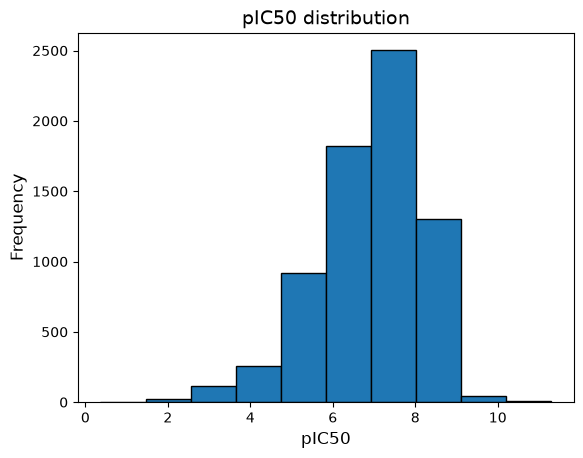

In [41]:
fig, ax = plt.subplots()

ax.hist(output_df['pIC50'], edgecolor="black")
ax.set_xlabel("pIC50", fontsize=12)
ax.set_ylabel("Frequency", fontsize=12)
ax.set_title("pIC50 distribution", fontsize=14)

#### Transform SMILES str dtype to molecule rdkit object


In [42]:
PandasTools.AddMoleculeColumnToFrame(output_df, smilesCol="canonical_smiles")

and we sort the dataset by pIC50

In [43]:
# Sort molecules by pIC50
output_df.sort_values(by="pIC50", ascending=False, inplace=True)

# Reset index
output_df.reset_index(drop=True, inplace=True)

,molecule_chembl_id,kinase,IC50,units,canonical_smiles,pIC50,ROMol
0,CHEMBL3694408,CDK9,5.000000e-03,nM,COc1ccc(F)cc1-c1cc(NC(=O)COc2ccc(Cl)cn2)ncn1,11.301030,
1,CHEMBL334285,CDK4,7.000000e-03,nM,O=C(Nc1cccc2c1C(=O)c1c(-c3ccc(C(=O)N4CCNCC4)s3...,11.154902,
2,CHEMBL3694406,CDK9,1.500000e-02,nM,COc1ccc(F)cc1-c1cc(NC(=O)Cc2cccnc2)ncn1,10.823909,
3,CHEMBL3694400,CDK9,1.800000e-02,nM,COc1ccc(F)cc1-c1cc(NC(=O)C2CCCNC2)ncn1,10.744727,
4,CHEMBL3694402,CDK9,1.900000e-02,nM,COc1ccccc1-c1cc(NC(=O)C2CCC(=O)NC2)ncn1,10.721246,
...,...,...,...,...,...,...,...
6994,CHEMBL276120,CDK1,1.000000e+07,nM,CC(C)[C@H](CO)N(Cc1ccc(F)cc1)c1nc(Nc2cccc(Cl)c...,2.000000,
6995,CHEMBL76921,CDK1,1.080000e+07,nM,COc1ccc(CNc2nc(N3CCN(C)CC3)nc3c2ncn3C(C)C)cc1,1.966576,
6996,CHEMBL78214,CDK1,3.300000e+07,nM,CC(C)[C@H](CO)Nc1nc(Nc2ccc(N)c(Cl)c2)c2ncn(C(C...,1.481486,
6997,CHEMBL311354,CDK1,5.200000e+07,nM,CC(C)[C@H](CO)Nc1nc(Nc2ccc(Cl)c(N)c2)c2ncn(C(C...,1.283997,

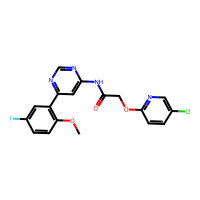
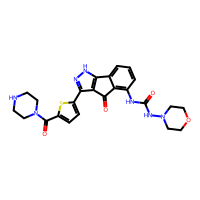
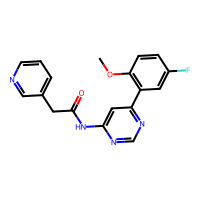
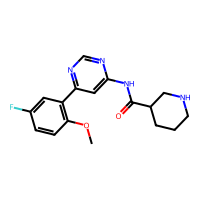
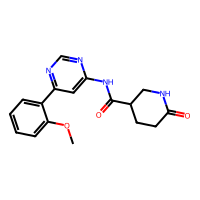
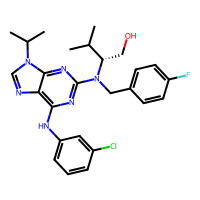
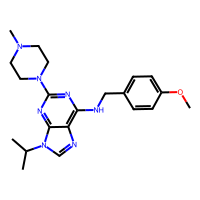
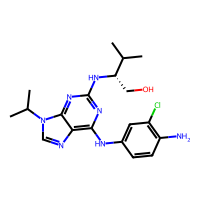
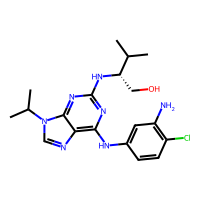
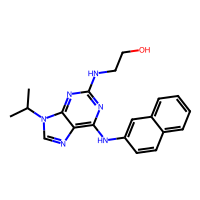

In [44]:
output_df

#### II.6 Write output data to file

We want to use this bioactivity-compound dataset in the following steps, thus we save the data as `csv` file. 
Note that it is advisable to drop the molecule column (which only contains an image of the molecules) when saving the data.

In [45]:
output_df.drop(columns=['ROMol'], inplace = True)

In [46]:
output_df

,molecule_chembl_id,kinase,IC50,units,canonical_smiles,pIC50
0,CHEMBL3694408,CDK9,5.000000e-03,nM,COc1ccc(F)cc1-c1cc(NC(=O)COc2ccc(Cl)cn2)ncn1,11.301030
1,CHEMBL334285,CDK4,7.000000e-03,nM,O=C(Nc1cccc2c1C(=O)c1c(-c3ccc(C(=O)N4CCNCC4)s3...,11.154902
2,CHEMBL3694406,CDK9,1.500000e-02,nM,COc1ccc(F)cc1-c1cc(NC(=O)Cc2cccnc2)ncn1,10.823909
3,CHEMBL3694400,CDK9,1.800000e-02,nM,COc1ccc(F)cc1-c1cc(NC(=O)C2CCCNC2)ncn1,10.744727
4,CHEMBL3694402,CDK9,1.900000e-02,nM,COc1ccccc1-c1cc(NC(=O)C2CCC(=O)NC2)ncn1,10.721246
...,...,...,...,...,...,...
6994,CHEMBL276120,CDK1,1.000000e+07,nM,CC(C)[C@H](CO)N(Cc1ccc(F)cc1)c1nc(Nc2cccc(Cl)c...,2.000000
6995,CHEMBL76921,CDK1,1.080000e+07,nM,COc1ccc(CNc2nc(N3CCN(C)CC3)nc3c2ncn3C(C)C)cc1,1.966576
6996,CHEMBL78214,CDK1,3.300000e+07,nM,CC(C)[C@H](CO)Nc1nc(Nc2ccc(N)c(Cl)c2)c2ncn(C(C...,1.481486
6997,CHEMBL311354,CDK1,5.200000e+07,nM,CC(C)[C@H](CO)Nc1nc(Nc2ccc(Cl)c(N)c2)c2ncn(C(C...,1.283997


In [50]:
# Go up one level from the current directory into the parent repo/folder
output_dir = Path.cwd().parent / "data"
output_dir.mkdir(parents=True, exist_ok=True)

output_df.to_csv(output_dir / "CDK_compounds.csv", index=False)

print(f"Successfully saved to {output_dir / 'CDK_compounds.csv'}")

Successfully saved to /home/adem/Downloads/Drug Discovery journey/Mastering Generative_ml models/Phase_0/VAE/project_01/phase_01/data/CDK_compounds.csv


In [49]:
ls

1.compound_data_aquisation.ipynb  3.gnn.ipynb
2.unwanted_filtering.ipynb        project_01/
